<a href="https://colab.research.google.com/github/RiteshD11/Customer-Churn-Prediction-model--Banking-/blob/main/BFSI_TUT_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [75]:

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Churn_Modelling.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Saving Churn_Modelling.csv to Churn_Modelling (1).csv
Dataset loaded successfully!
Shape: (10000, 14)


In [76]:
print("=== First 5 rows ===")
print(df.head())

print("\n=== Column names ===")
print(df.columns.tolist())

print("\n=== Data types and non-null counts ===")
print(df.info())

print("\n=== Statistical Summary ===")
print(df.describe())

=== First 5 rows ===
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63   

In [77]:
# RowNumber, CustomerId, Surname are unique identifiers
# They have ZERO predictive power — model must not see them
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print(f"Shape after dropping ID columns: {df.shape}")
# Should now be (10000, 11)
print(df.head())

Shape after dropping ID columns: (10000, 11)
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


In [78]:
print("=== Target Variable Distribution ===")
print(df['Exited'].value_counts())
print("\n=== In percentage ===")
print(df['Exited'].value_counts(normalize=True) * 100)

=== Target Variable Distribution ===
Exited
0    7963
1    2037
Name: count, dtype: int64

=== In percentage ===
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


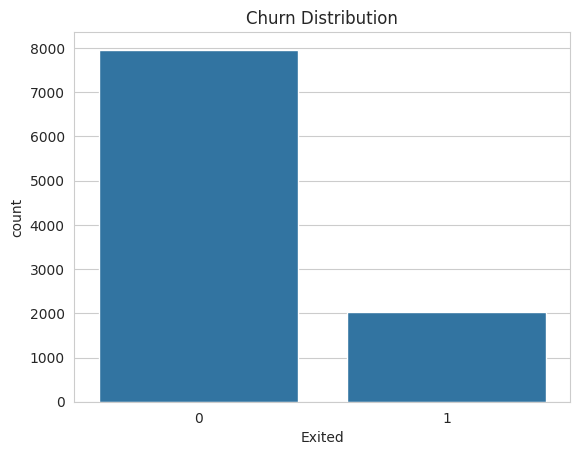

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target variable distribution
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

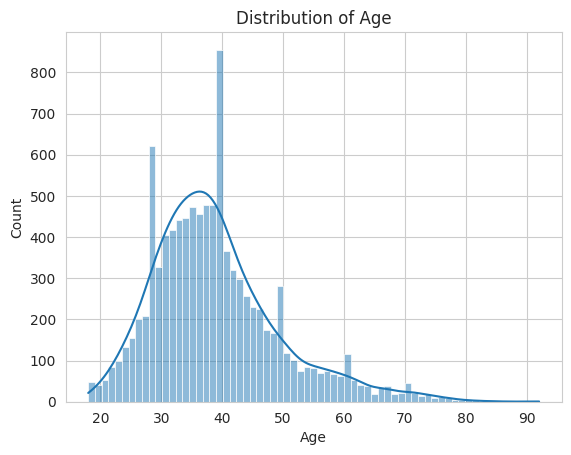

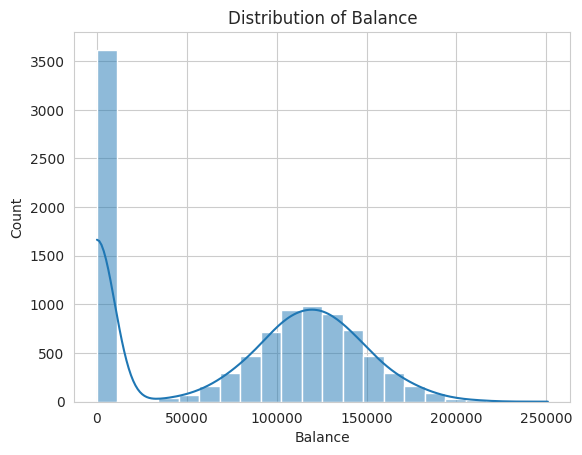

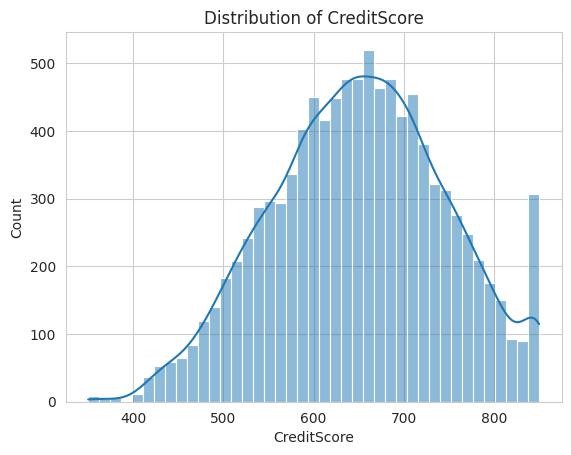

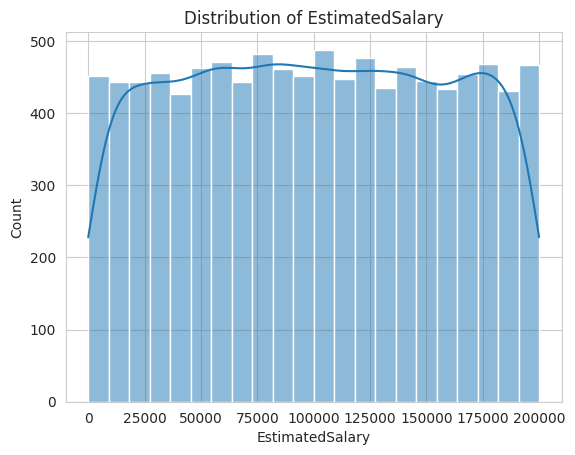

In [80]:
num_cols = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

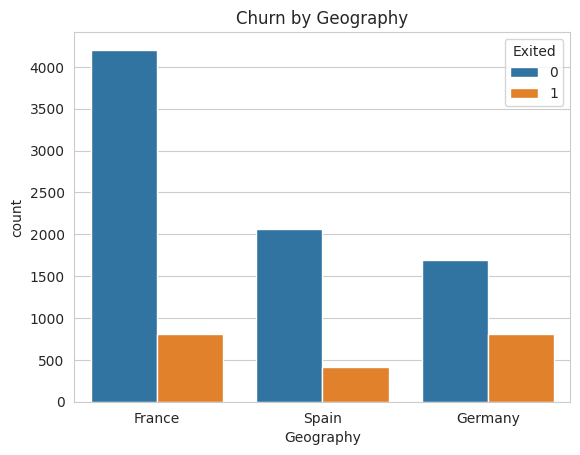

In [81]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title("Churn by Geography")
plt.show()

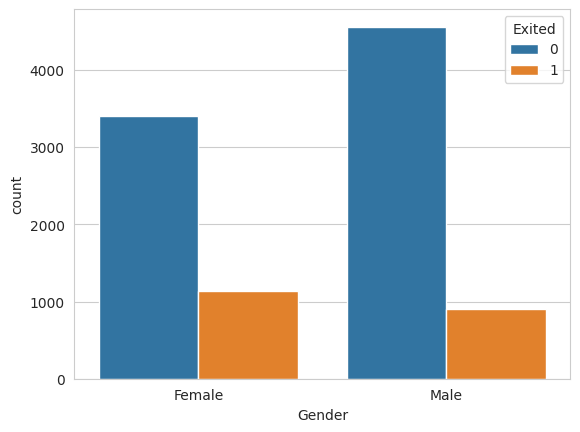

In [82]:
sns.countplot(x='Gender', hue='Exited', data=df)
plt.show()

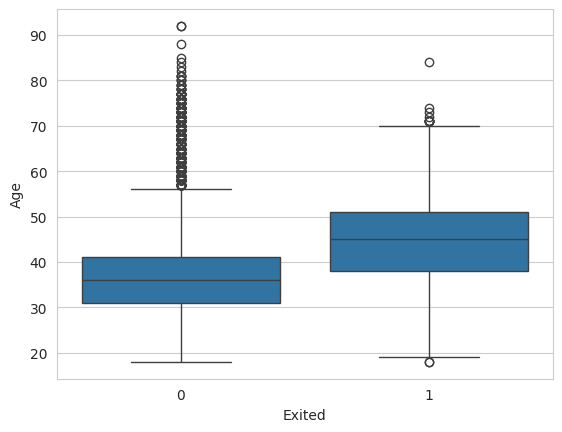

In [83]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.show()

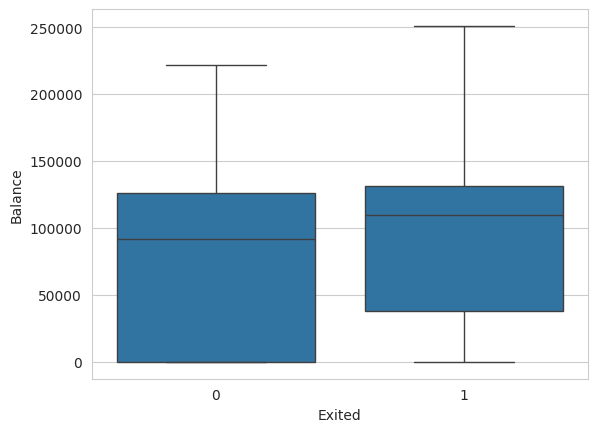

In [84]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.show()

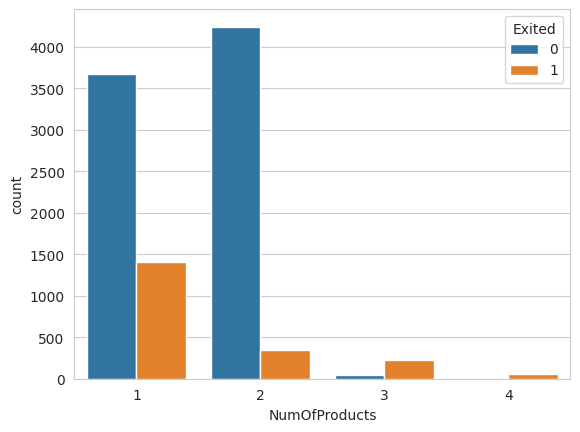

In [85]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.show()

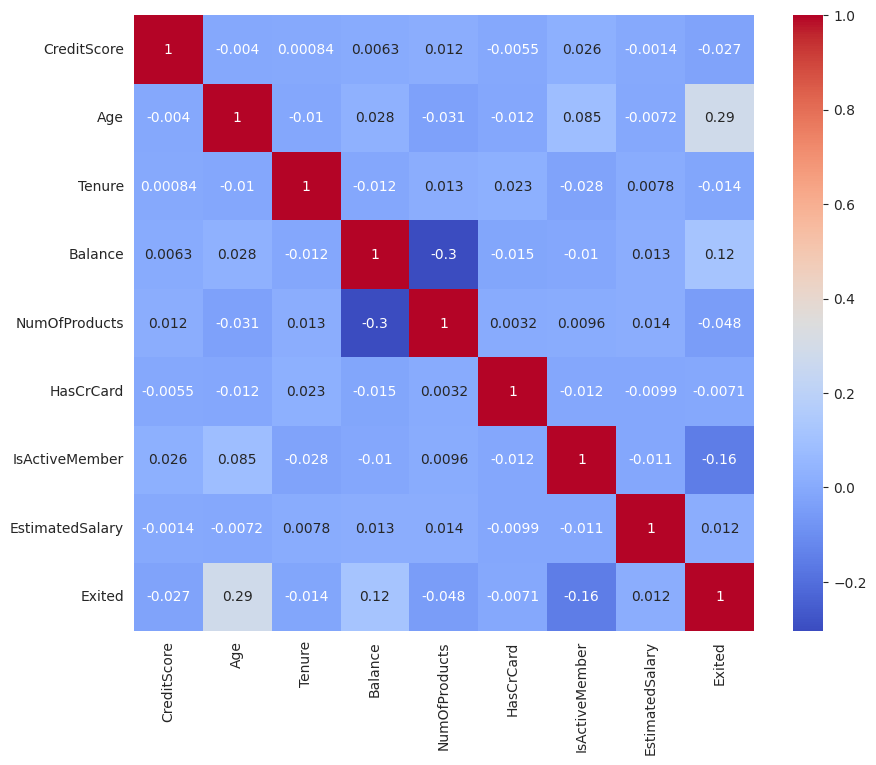

In [86]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [87]:
df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [88]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [89]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [92]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [93]:
from collections import Counter
print(Counter(y_train))

Counter({0: 6356, 1: 6356})


Step 4 : Featured Engineering


In [94]:

df['Balance_Salary_Ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)

In [95]:
df['Products_Per_Tenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

In [96]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18, 30, 50, 100],
    labels=['Young', 'Middle', 'Senior']
)

In [97]:
df = pd.get_dummies(df, columns=['Age_Group'], drop_first=True)

In [98]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [101]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [102]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                 Feature  Importance
2                    Age    0.214909
5          NumOfProducts    0.140085
4                Balance    0.089195
0            CreditScore    0.080119
8        EstimatedSalary    0.079975
12   Products_Per_Tenure    0.079272
11  Balance_Salary_Ratio    0.077879
3                 Tenure    0.067127
7         IsActiveMember    0.049005
14      Age_Group_Senior    0.026836


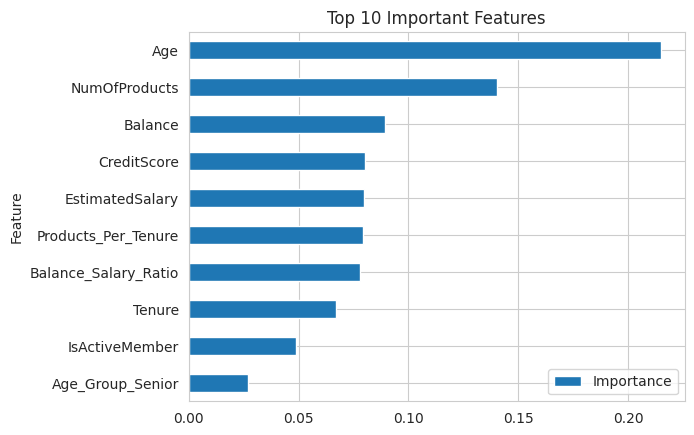

In [103]:
import matplotlib.pyplot as plt

importance_df.head(10).plot(
    kind='barh', x='Feature', y='Importance'
)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

In [105]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.718
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1607
           1       0.38      0.72      0.50       393

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.72      0.74      2000



In [106]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7775
              precision    recall  f1-score   support

           0       0.88      0.83      0.86      1607
           1       0.45      0.55      0.49       393

    accuracy                           0.78      2000
   macro avg       0.66      0.69      0.67      2000
weighted avg       0.80      0.78      0.79      2000



In [107]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.847
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1607
           1       0.62      0.58      0.60       393

    accuracy                           0.85      2000
   macro avg       0.76      0.75      0.75      2000
weighted avg       0.84      0.85      0.84      2000



In [108]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8345
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1607
           1       0.56      0.69      0.62       393

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000



In [109]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb)
}

for model, score in results.items():
    print(f"{model}: {score}")

Logistic Regression: 0.718
Decision Tree: 0.7775
Random Forest: 0.847
Gradient Boosting: 0.8345



 STEP 6 — Model Evaluation (CONFUSION MATRIX + ROC CURVE)

Confusion Matrix

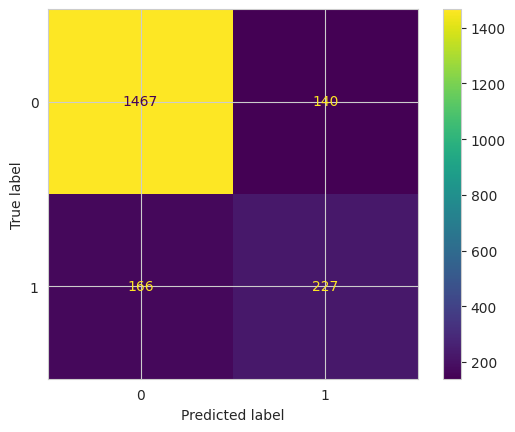

In [110]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

ROC Curve

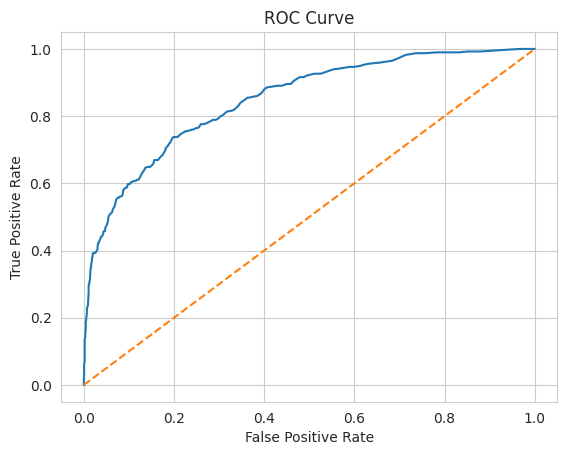

In [111]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

AUC Score

In [112]:
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)

AUC Score: 0.8483693320096081


STEP 7 — BUSINESS INSIGHTS (MOST SCORING PART)

Key Insights

1. Customers with higher age are more likely to churn
2. Customers with higher account balance show higher churn probability
3. Customers using fewer products (1 product) churn the most
4. Inactive members are at higher risk of leaving
5. Customers from Germany show the highest churn rate

Top Predictors of Churn

- Age
- Balance
- NumOfProducts
- IsActiveMember
- Balance_Salary_Ratio

Business Recommendations

1. Target high-risk customers with personalized offers
2. Increase engagement by promoting multiple banking products
3. Focus retention strategies on older customers
4. Improve services in high churn regions like Germany
5. Encourage inactive users through rewards and communication

How Bank Will Use This Model (REAL-WORLD FLOW)
1. Run model monthly on all customers
2. Assign churn probability score (0 to 1)
3. Flag customers with score > 0.7 as high risk
4. Send list to retention team
5. Take actions like offers, calls, or benefits

Ethical Considerations

1. Model bias may affect certain age groups or regions
2. Customers should not be unfairly targeted or ignored
3. Data privacy must be maintained
4. Transparency in AI decisions is important

**Now Model Testing we perform on the unseen , data . model is trained and now it can run on unseen data , so we verify it**

In [113]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.847
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1607
           1       0.62      0.58      0.60       393

    accuracy                           0.85      2000
   macro avg       0.76      0.75      0.75      2000
weighted avg       0.84      0.85      0.84      2000



The model is validated using unseen test data to ensure generalization.

.

Test with New Customer (REAL-WORLD TEST)

In [114]:
feature_columns = X.columns

In [115]:
import pandas as pd

new_customer = pd.DataFrame([{
    'CreditScore': 600,
    'Gender': 1,
    'Age': 40,
    'Tenure': 3,
    'Balance': 60000,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 50000,

    'Geography_Germany': 1,
    'Geography_Spain': 0,

    'Balance_Salary_Ratio': 60000/50000,
    'Products_Per_Tenure': 2/(3+1),

    'Age_Group_Middle': 1,
    'Age_Group_Senior': 0
}])

In [116]:
new_customer = new_customer.reindex(columns=feature_columns, fill_value=0)

In [117]:
new_customer_scaled = scaler.transform(new_customer)

In [118]:
prediction = rf.predict(new_customer_scaled)
probability = rf.predict_proba(new_customer_scaled)

print("Prediction:", "Churn" if prediction[0]==1 else "No Churn")
print("Probability:", probability[0][1])

Prediction: No Churn
Probability: 0.23


In [119]:
print("Expected features:", len(X.columns))
print("Input features:", new_customer.shape[1])

Expected features: 15
Input features: 15


So , Model testing with raw data  to usefull output

Test Case 1:

HIGH CHURN ( Risky Customer)

In [120]:
new_customer.loc[0] = 0

new_customer['CreditScore'] = 450
new_customer['Gender'] = 1
new_customer['Age'] = 55
new_customer['Tenure'] = 1
new_customer['Balance'] = 120000
new_customer['NumOfProducts'] = 1
new_customer['HasCrCard'] = 1
new_customer['IsActiveMember'] = 0
new_customer['EstimatedSalary'] = 40000

# Geography
new_customer['Geography_Germany'] = 1
new_customer['Geography_Spain'] = 0

# Feature Engineering
new_customer['Balance_Salary_Ratio'] = 120000/40000
new_customer['Products_Per_Tenure'] = 1/(1+1)

# Age group
new_customer['Age_Group_Middle'] = 0
new_customer['Age_Group_Senior'] = 1

In [121]:
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

new_customer_scaled = scaler.transform(new_customer)

prediction = rf.predict(new_customer_scaled)
probability = rf.predict_proba(new_customer_scaled)

print("Prediction:", "Churn" if prediction[0]==1 else "No Churn")
print("Probability:", probability[0][1])

Prediction: Churn
Probability: 0.975


TEST CASE 2 — LOW CHURN ( Safe Customer)


> expected output should be : No Curn





In [122]:
new_customer.loc[0] = 0

new_customer['CreditScore'] = 750
new_customer['Gender'] = 0
new_customer['Age'] = 30
new_customer['Tenure'] = 5
new_customer['Balance'] = 20000
new_customer['NumOfProducts'] = 3
new_customer['HasCrCard'] = 1
new_customer['IsActiveMember'] = 1
new_customer['EstimatedSalary'] = 80000

# Geography
new_customer['Geography_Germany'] = 0
new_customer['Geography_Spain'] = 0

# Feature Engineering
new_customer['Balance_Salary_Ratio'] = 20000/80000
new_customer['Products_Per_Tenure'] = 3/(5+1)

# Age group
new_customer['Age_Group_Middle'] = 1
new_customer['Age_Group_Senior'] = 0

In [123]:
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

new_customer_scaled = scaler.transform(new_customer)

prediction = rf.predict(new_customer_scaled)
probability = rf.predict_proba(new_customer_scaled)

print("Prediction:", "Churn" if prediction[0]==1 else "No Churn")
print("Probability:", probability[0][1])

Prediction: Churn
Probability: 0.795


TEST CASE 3 — MEDIUM RISK (🟡 Borderline)

> Expected Output is : Depends on model (~50-60%)



In [124]:
new_customer.loc[0] = 0

new_customer['CreditScore'] = 600
new_customer['Gender'] = 1
new_customer['Age'] = 40
new_customer['Tenure'] = 3
new_customer['Balance'] = 60000
new_customer['NumOfProducts'] = 2
new_customer['HasCrCard'] = 1
new_customer['IsActiveMember'] = 1
new_customer['EstimatedSalary'] = 50000

# Geography
new_customer['Geography_Germany'] = 0
new_customer['Geography_Spain'] = 1

# Feature Engineering
new_customer['Balance_Salary_Ratio'] = 60000/50000
new_customer['Products_Per_Tenure'] = 2/(3+1)

# Age group
new_customer['Age_Group_Middle'] = 1
new_customer['Age_Group_Senior'] = 0



```
Now output of each data is
```



In [125]:
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

new_customer_scaled = scaler.transform(new_customer)

prediction = rf.predict(new_customer_scaled)
probability = rf.predict_proba(new_customer_scaled)

print("Prediction:", "Churn" if prediction[0]==1 else "No Churn")
print("Probability:", probability[0][1])

Prediction: No Churn
Probability: 0.37


In [126]:
new_customer.loc[0] = 0

new_customer['CreditScore'] = 700
new_customer['Gender'] = 1
new_customer['Age'] = 35
new_customer['Tenure'] = 4
new_customer['Balance'] = 150000   # ₹1.5 lakh
new_customer['NumOfProducts'] = 2
new_customer['HasCrCard'] = 1
new_customer['IsActiveMember'] = 1
new_customer['EstimatedSalary'] = 600000   # ₹6 lakh/year

# Geography (treat as region)
new_customer['Geography_Germany'] = 1
new_customer['Geography_Spain'] = 0

# Feature Engineering
new_customer['Balance_Salary_Ratio'] = 150000/600000
new_customer['Products_Per_Tenure'] = 2/(4+1)

# Age group
new_customer['Age_Group_Middle'] = 1
new_customer['Age_Group_Senior'] = 0

In [127]:
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

new_customer_scaled = scaler.transform(new_customer)

prediction = rf.predict(new_customer_scaled)
probability = rf.predict_proba(new_customer_scaled)

print("Prediction:", "Churn" if prediction[0]==1 else "No Churn")
print("Probability:", probability[0][1])

Prediction: No Churn
Probability: 0.065
